# Load Data

In [1]:
# Import pandas library to work with data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

In [2]:
# Load the Excel dataset into a DataFrame
df = pd.read_excel("dataset -P657 (1).xlsx")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'dataset -P657 (1).xlsx'

In [ ]:
# Display basic information about the dataset
df.info()

In [ ]:
# Check how many missing (null) values are present in each column
df.isnull().sum()

In [ ]:
# Combine 'title' and 'body' columns into a single 'review' column
df['review'] = df['title'] + " " + df['body']
df

In [ ]:
# Create a function to convert rating into sentiment label
def get_sentiment(rating):
    if rating >= 4:
        return "Positive"   # high rating → positive sentiment
    elif rating <= 2:
        return "Negative"   # low rating → negative sentiment
    else:
        return "Neutral"    # medium rating → neutral sentiment

# Apply the function to the 'rating' column and create a new 'sentiment' column
df['sentiment'] = df['rating'].apply(get_sentiment)

In [ ]:
# Count how many reviews belong to each sentiment category
df['sentiment'].value_counts()

In [ ]:
df = df[['review', 'sentiment']]
df

In [ ]:
# Install emoji library to handle emojis in text
!pip install emoji
# Import emoji module
import emoji

# Function to convert emojis into text
def convert_emojis(text):
    return emoji.demojize(str(text))

# Apply function to all reviews and update the 'review' column
df.loc[:, 'review'] = df['review'].apply(convert_emojis)

In [ ]:
!pip install langid

import langid

# Function to detect language
def detect_language(text):
    try:
        lang, prob = langid.classify(str(text))
        return lang
    except:
        return "unknown"

df['language'] = df['review'].apply(detect_language)


In [ ]:
# Check results
print(df[['review','language']].head())

In [ ]:
# Create a count plot to show number of reviews in each language
sns.countplot(x='language', data=df)
plt.title("Language Distribution")
plt.show()

“The dataset was predominantly English (~98%), so I filtered non-English reviews to maintain consistency and avoid introducing noise into the model.”

In [ ]:
df.head()

In [5]:
# Filter the dataset to keep only English ('en') reviews
df = df[df['language'] == 'en']

# Check the shape of the dataset (rows, columns) after filtering
df.shape

NameError: name 'df' is not defined

In [6]:
df.head()

NameError: name 'df' is not defined

In [7]:
import nltk
from nltk.corpus import stopwords  # list of common words like "is", "the"
from nltk.stem import WordNetLemmatizer  # to convert words to base form

ModuleNotFoundError: No module named 'nltk'

In [8]:
# Stopwords are common words like "is", "the", "and" that do not add much meaning.
# We remove them to reduce noise and focus on important words.
# But we keep words like "not", "no", "nor" because they affect sentiment.

In [9]:
# Get English stopwords and keep important words like 'not', 'no', 'nor'
stop_words = set(stopwords.words('english')) - {'not', 'no', 'nor'}

lemmatizer = WordNetLemmatizer()

# Function to clean each review
def clean_text(text):
    text = text.lower()  # convert text to lowercase

    # remove numbers, punctuation, and special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # split text into words
    words = text.split()

    # remove stopwords (but keep important ones like 'not')
    words = [word for word in words if word not in stop_words]

    # convert words to their base form (e.g., running → run)
    words = [lemmatizer.lemmatize(word) for word in words]

    # join words back into a sentence
    return " ".join(words)

# Apply the cleaning function to all reviews
df['clean_review'] = df['review'].apply(clean_text)

NameError: name 'stopwords' is not defined

In [10]:
df.head()

NameError: name 'df' is not defined

In [11]:
# Create a count plot to show number of reviews in each sentiment category
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

NameError: name 'df' is not defined

In [12]:
# Create a new column 'length' which stores the number of characters in each cleaned review
df['length'] = df['clean_review'].apply(len)

# Plot a histogram to see how review lengths are distributed
sns.histplot(df['length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

NameError: name 'df' is not defined

In [13]:
# Import WordCloud to create a visual representation of word frequencies
from wordcloud import WordCloud

# Generate a word cloud from all cleaned reviews
# Words that appear more frequently will be shown bigger
wordcloud = WordCloud(width=4000, height=2000,background_color='white',colormap='viridis').generate(" ".join(df['clean_review']))

# Display the word cloud image
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud")
plt.show()

ModuleNotFoundError: No module named 'wordcloud'

In [14]:
# Import Counter to count frequency of words
from collections import Counter

# Combine all cleaned reviews into one big string and split into individual word
# Count how many times each word appears and get top 20 most common words
words = Counter(" ".join(df['clean_review']).split()).most_common(20)

NameError: name 'df' is not defined

In [15]:
# Convert the result into a DataFrame for easy plotting
words_df = pd.DataFrame(words, columns=['word', 'count'])

# Create a bar plot showing top 20 words and their frequencies
sns.barplot(x='count', y='word', data=words_df)
plt.title("Top 20 Words")
plt.show()

NameError: name 'words' is not defined

In [16]:
df.head()

NameError: name 'df' is not defined

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
# Applying LabelEncoder to the newly created 'label' column
le = LabelEncoder()
df["sentiment"] = le.fit_transform(df["sentiment"])

df.head()

NameError: name 'df' is not defined

#### Feature Extraction using TF-IDF

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [30]:
X = df['clean_review'] # input features
y = df['sentiment'] # target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
# Convert text into numerical form
tfidf = TfidfVectorizer(max_features=2000,ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

#### MODEL BUILDING

##### LOGISTIC REGRESSION

In [32]:
lr = LogisticRegression(max_iter=1000)

# Train the model on training data
lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [33]:
lr_pred = lr.predict(X_test_tfidf)

In [34]:
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report for Logistic Regression:\n")
print(classification_report(y_test, lr_pred))

Accuracy: 0.7985865724381626

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.77      0.87      0.82        87
           1       0.80      0.09      0.16        44
           2       0.82      0.96      0.88       152

    accuracy                           0.80       283
   macro avg       0.79      0.64      0.62       283
weighted avg       0.80      0.80      0.75       283



##### Decision Tree

In [35]:
dt = DecisionTreeClassifier(random_state=42) 
dt.fit(X_train_tfidf, y_train)

DecisionTreeClassifier(random_state=42)

In [36]:
dt_pred = dt.predict(X_test_tfidf)

In [37]:
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report for Decision Tree:")
print(classification_report(y_test, dt_pred))


Accuracy: 0.6607773851590106

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.63      0.71      0.67        87
           1       0.30      0.27      0.29        44
           2       0.78      0.74      0.76       152

    accuracy                           0.66       283
   macro avg       0.57      0.58      0.57       283
weighted avg       0.66      0.66      0.66       283



##### SVM

In [38]:
svm = LinearSVC(random_state=42)

svm.fit(X_train_tfidf, y_train)

LinearSVC(random_state=42)

In [39]:
svm_pred = svm.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("\nClassification Report for SVM:")
print(classification_report(y_test, svm_pred))

Accuracy: 0.7773851590106007

Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.74      0.89      0.81        87
           1       0.33      0.11      0.17        44
           2       0.84      0.91      0.87       152

    accuracy                           0.78       283
   macro avg       0.64      0.64      0.62       283
weighted avg       0.73      0.78      0.74       283



##### Random Forest

In [40]:
rf = RandomForestClassifier(random_state=42) 
rf.fit(X_train_tfidf, y_train)

RandomForestClassifier(random_state=42)

In [41]:
rf_pred = rf.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, rf_pred))

Accuracy: 0.7809187279151943

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78        87
           1       1.00      0.02      0.04        44
           2       0.80      0.98      0.88       152

    accuracy                           0.78       283
   macro avg       0.85      0.61      0.57       283
weighted avg       0.81      0.78      0.72       283



##### Naive Bayes

In [42]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [43]:
nb_pred = nb.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, nb_pred))

print("\nClassification Report for Naive Bayes:")
print(classification_report(y_test, nb_pred))

Accuracy: 0.7703180212014135

Classification Report for Naive Bayes:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        87
           1       0.00      0.00      0.00        44
           2       0.74      0.97      0.84       152

    accuracy                           0.77       283
   macro avg       0.53      0.59      0.55       283
weighted avg       0.66      0.77      0.70       283



C:\Users\Smriti thapa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smriti thapa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smriti thapa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##### LightGBM

In [44]:
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train_tfidf, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008871 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8363
[LightGBM] [Info] Number of data points in the train set: 1132, number of used features: 371
[LightGBM] [Info] Start training from score -1.018026
[LightGBM] [Info] Start training from score -1.994789
[LightGBM] [Info] Start training from score -0.687861


LGBMClassifier(random_state=42)

In [45]:
lgbm_pred = lgbm.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, lgbm_pred))
print("\nClassification Report for LightGBM:")
print(classification_report(y_test, lgbm_pred))

Accuracy: 0.7879858657243817

Classification Report for LightGBM:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        87
           1       0.35      0.16      0.22        44
           2       0.85      0.93      0.89       152

    accuracy                           0.79       283
   macro avg       0.66      0.65      0.64       283
weighted avg       0.75      0.79      0.76       283



C:\Users\Smriti thapa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Metrics Comparison

In [46]:
results = []

models = [
    ("Logistic Regression", lr_pred),
    ("Naive Bayes", nb_pred),
    ("SVM", svm_pred),
    ("Decision Tree", dt_pred),
    ("Random Forest", rf_pred),
    ("LightGBM", lgbm_pred)  
]

for name, pred in models:
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred,average='weighted'),
        "Recall": recall_score(y_test, pred,average='weighted'),
        "F1 Score": f1_score(y_test, pred,average='weighted')
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df

C:\Users\Smriti thapa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
5,LightGBM,0.787986,0.747861,0.787986,0.760679
0,Logistic Regression,0.798587,0.798465,0.798587,0.750428
2,SVM,0.777385,0.731387,0.777385,0.743335
4,Random Forest,0.780919,0.813192,0.780919,0.718909
1,Naive Bayes,0.770318,0.656726,0.770318,0.704824
3,Decision Tree,0.660777,0.660645,0.660777,0.659454


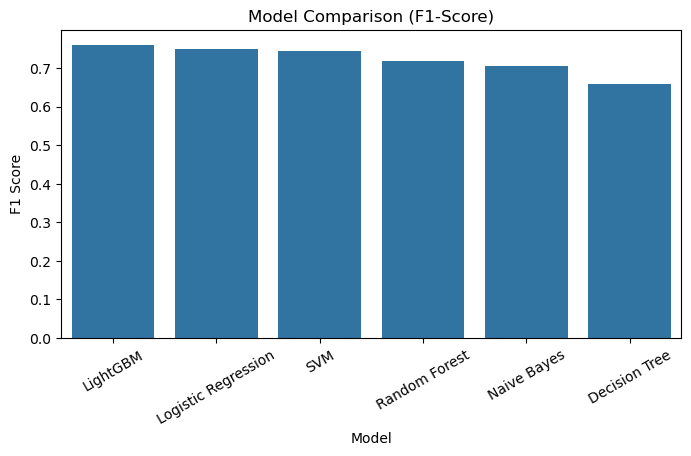

In [47]:
plt.figure(figsize=(8,4))
sns.barplot( x="Model",y="F1 Score",data=results_df)
plt.title("Model Comparison (F1-Score)")
plt.xticks(rotation=30)
plt.show()

### Hyperparameter Tuning

In [48]:
from sklearn.model_selection import GridSearchCV

##### Logistic Regression

In [49]:
# Define Parameter Grid
lr_param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

In [50]:
# Initialize Base Model
lr = LogisticRegression(max_iter=1000)

In [51]:
# Grid Search
lr_grid = GridSearchCV(
    estimator=lr,
    param_grid=lr_param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

In [52]:
lr_grid.fit(X_train_tfidf, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']},
             scoring='f1_weighted')

In [53]:
lr_best = lr_grid.best_estimator_
print("\nBest Logistic Regression Parameters:")
print(lr_grid.best_params_)


Best Logistic Regression Parameters:
{'C': 10, 'solver': 'liblinear'}


In [54]:
lr_best_pred = lr_best.predict(X_test_tfidf)

##### Decision Tree

In [55]:
# Define Parameter Grid
dt_param_grid = {
    "max_depth": [ 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}
# Initialize Base Model
dt = DecisionTreeClassifier(random_state=42)

In [56]:
# Grid Search
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)

dt_grid.fit(X_train_tfidf, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 15, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1_weighted')

In [57]:

dt_best = dt_grid.best_estimator_

print("\nBest Decision Tree Parameters:")
print(dt_grid.best_params_)


Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [58]:
dt_best_pred = dt_best.predict(X_test_tfidf)

##### SVM

In [59]:
# Define Parameter Grid
svm_params = {'C': [0.10, 0.1, 1, 10], 'loss': ['hinge', 'squared_hinge']}
# Initialize Base Model
svm = LinearSVC()

In [60]:
svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_params,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train_tfidf, y_train)

GridSearchCV(cv=5, estimator=LinearSVC(), n_jobs=-1,
             param_grid={'C': [0.1, 0.1, 1, 10],
                         'loss': ['hinge', 'squared_hinge']},
             scoring='f1_weighted')

In [61]:
svm_best = svm_grid.best_estimator_
print("\nBest SVM Parameters:")
print(svm_grid.best_params_)


Best SVM Parameters:
{'C': 1, 'loss': 'squared_hinge'}


In [62]:
svm_best_pred = svm_best.predict(X_test_tfidf)

##### Random Forest

In [63]:
# Define Parameter Grid
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
# Initialize Base Model
rf = RandomForestClassifier(random_state=42)

In [64]:
# Grid Search
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train_tfidf, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1_weighted')

In [65]:
rf_best = rf_grid.best_estimator_

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)


Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [66]:
rf_best_pred = rf_best.predict(X_test_tfidf)

##### Naive Bayes

In [67]:
# Define Parameter Grid
nb_param_grid = {
    'alpha': [0.5, 1.0, 1.5]
}

# Initialize Base Model
nb = MultinomialNB()

In [68]:
# Grid Search
nb_grid = GridSearchCV(
    estimator=nb,
    param_grid=nb_param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

nb_grid.fit(X_train_tfidf, y_train)

GridSearchCV(cv=5, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': [0.5, 1.0, 1.5]}, scoring='f1_weighted')

In [69]:
nb_best = nb_grid.best_estimator_

print("\nBest Naive Bayes Parameters:")
print(nb_grid.best_params_)


Best Naive Bayes Parameters:
{'alpha': 0.5}


In [70]:
nb_best_pred = nb_best.predict(X_test_tfidf)

##### LightGBM

In [71]:
# Define Parameter Grid
lgbm_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50]
}

# Initialize Base Model
lgbm = LGBMClassifier(random_state=42)

In [72]:
# Grid Search
lgbm_grid = GridSearchCV(
    estimator=lgbm,
    param_grid=lgbm_param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

lgbm_grid.fit(X_train_tfidf, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8363
[LightGBM] [Info] Number of data points in the train set: 1132, number of used features: 371
[LightGBM] [Info] Start training from score -1.018026
[LightGBM] [Info] Start training from score -1.994789
[LightGBM] [Info] Start training from score -0.687861
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

GridSearchCV(cv=3, estimator=LGBMClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1],
                         'n_estimators': [100, 200], 'num_leaves': [31, 50]},
             scoring='f1_weighted', verbose=1)

In [73]:
lgbm_best = lgbm_grid.best_estimator_

print("\nBest LightGBM Parameters:")
print(lgbm_grid.best_params_)


Best LightGBM Parameters:
{'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 50}


In [74]:
lgbm_best_pred = lgbm_best.predict(X_test_tfidf)

C:\Users\Smriti thapa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


###  Comparison Table for Tuned models

In [75]:
tuned_results = []

tuned_models = [
    ("Logistic Regression", lr_best_pred),
    ("Naive Bayes", nb_best_pred),
    ("SVM", svm_best_pred),
    ("Decision Tree", dt_best_pred),
    ("Random Forest", rf_best_pred),
    ("LightGBM", lgbm_best_pred)
]

for name, pred in tuned_models:
    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average='weighted'),
        "Recall": recall_score(y_test, pred, average='weighted'),
        "F1 Score": f1_score(y_test, pred, average='weighted')
    })

# Convert to DataFrame
results_df = pd.DataFrame(tuned_results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df

C:\Users\Smriti thapa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smriti thapa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
5,LightGBM,0.791519,0.747964,0.791519,0.758849
0,Logistic Regression,0.780919,0.739804,0.780919,0.747941
2,SVM,0.777385,0.731387,0.777385,0.743335
4,Random Forest,0.787986,0.666294,0.787986,0.721044
1,Naive Bayes,0.777385,0.659173,0.777385,0.711125
3,Decision Tree,0.607774,0.618325,0.607774,0.608283


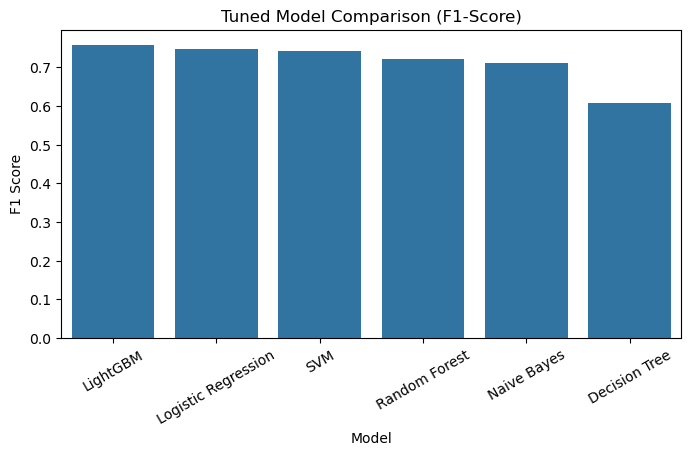

In [76]:
plt.figure(figsize=(8,4))
sns.barplot( x="Model",y="F1 Score",data=results_df)
plt.title("Tuned Model Comparison (F1-Score)")
plt.xticks(rotation=30)
plt.show()

In [77]:
!pip install streamlit

In [78]:
import re
import pickle
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from sklearn.preprocessing import FunctionTransformer
import joblib

In [79]:

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text

def preprocess_wrapper(texts):
    return [clean_text(t) for t in texts]



In [81]:
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

pipeline = Pipeline([
    ("cleaner", FunctionTransformer(preprocess_wrapper, validate=False)),
    ("vectorizer", tfidf),
    ("model", lgbm_best)
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "pipeline.pkl")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011813 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8363
[LightGBM] [Info] Number of data points in the train set: 1132, number of used features: 371
[LightGBM] [Info] Start training from score -1.018026
[LightGBM] [Info] Start training from score -1.994789
[LightGBM] [Info] Start training from score -0.687861
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

['pipeline.pkl']